In [28]:
# Modules Load/Reload
# ── CONFIG ────────────────────────────────────────────────────────────────────
DEV_MODE = True   # True: reload modules on every run | False: simple import
# ─────────────────────────────────────────────────────────────────────────────
%matplotlib inline
import os
import warnings
import io
import contextlib
import pandas as pd
warnings.filterwarnings("ignore")

# Relative folders by default — no dependency on any machine-specific path. All
# shared modules (ticker_provider, data_engine, sector_lookup, regime_detector,
# options_scanner) come from the installed trading-shared-data package (see
# requirements.txt); scorer_mr, backtester, stop_loss_forensics, and
# option_move_tracker are specific to this repo.
#
# OPTIONS_ARCHIVE_FOLDER can be overridden via an env var (e.g. to point at a
# shared, cross-project data folder locally) without touching this notebook —
# keeps the committed default portable for anyone else who clones it.
DATA_FOLDER            = "data"
OPTIONS_ARCHIVE_FOLDER = os.environ.get("OPTIONS_ARCHIVE_FOLDER", "options_archive")

if DEV_MODE:
    import importlib
    import ticker_provider      as _tp; importlib.reload(_tp)
    import data_engine          as _de; importlib.reload(_de)
    import sector_lookup        as _sl; importlib.reload(_sl)
    import regime_detector      as _rd; importlib.reload(_rd)
    import scorer_mr            as _sm; importlib.reload(_sm)
    import options_scanner      as _os; importlib.reload(_os)
    import option_move_tracker  as _om; importlib.reload(_om)
    import backtester           as _bt; importlib.reload(_bt)
    import stop_loss_forensics  as _slf; importlib.reload(_slf)

from ticker_provider     import get_tickers
from data_engine         import download_sp500_data, download_universe_data
from sector_lookup       import get_sectors
from sector_lookup       import get_sectors_and_caps
from regime_detector     import RegimeDetector
from options_scanner     import OptionsScanner
from option_move_tracker import run_option_move_backtest, summarize_option_backtest, print_option_backtest_report
from stop_loss_forensics import StopLossForensics
from contextlib          import redirect_stdout
import scorer_mr
import backtester
print(f"✅ Modules {'reloaded' if DEV_MODE else 'imported'} | DEV_MODE={'ON' if DEV_MODE else 'OFF'}")


✅ Modules reloaded | DEV_MODE=ON


In [102]:
# CONFIG
# Available universes (see ticker_provider.py SOURCES):
# US:     sp500, nasdaq100, dow30, russell2000
# Europe: dax40, cac40, ftse100, eurostoxx50, aex25, ftse_mib, ibex35
# Change here for a different universe -- NOT hardcoded to sp500.
UNIVERSE       = "sp500"
DATA_PERIOD    = "max"       
UNIVERSE_START = "2010-01-01"  # point-in-time membership window (survivorship-bias-free)
UNIVERSE_END   = "2026-12-31"  # -- independent of BACKTEST_START/END below, don't link them

# ── Cache policy (hours before re-downloading) ───────────────────────────────
TICKERS_CACHE_HOURS = 168   # ticker list: weekly
DATA_CACHE_HOURS    = 24    # OHLCV: daily
SECTORS_CACHE_HOURS = 24 * 30  # sector classification: monthly (rarely changes)

# ── Scanner ───────────────────────────────────────────────────────────────
TOP_N          = 60
MAX_PER_SECTOR = 30
MIN_SCORE      = 1.0

# ── MR scoring weights (must sum to 1.0) ─────────────────────────
W_RSI      = 0.30
W_BB       = 0.20
W_MR       = 0.15
W_PCR      = 0.15
W_STOCHRSI = 0.10
W_WILLIAMS = 0.10

assert abs(W_RSI + W_BB + W_MR + W_PCR + W_STOCHRSI + W_WILLIAMS - 1.0) < 1e-9, (
    "❌ MR weights do not sum to 1.0"
)

# ── Technical periods/thresholds (now REALLY adjustable, not just module defaults) ──
RSI_PERIOD       = 14
BB_PERIOD        = 20
BB_STD           = 2.0
MR_PERIOD        = 252   # 1 year, for z-score mean reversion
ATR_PERIOD       = 14
VOLUME_PERIOD    = 20
STOCH_RSI_PERIOD = 14
STOCH_SMOOTH_K   = 3
STOCH_SMOOTH_D   = 3
WILLIAMS_PERIOD  = 14

# ── Hard filters ─────────────────────────────────────────────────────────────
RSI_MAX        = 100.0     # RSI above this -> excluded
MIN_AVG_VOLUME = 100_000  # minimum average daily volume

# ── Market Cap Filter ─────────────────────────────────────────────────────────
# CAP_TIER: 1-5, or None for no market cap filter
# Tiers
#   1 = Small-cap        : $0      – $15B    (smaller names of S&P500)
#   2 = Mid-cap           : $15B    – $50B
#   3 = Large-cap          : $50B    – $150B
#   4 = Mega-cap           : $150B   – $500B
#   5 = Ultra Mega-cap     : $500B   – ∞        (bigger names of S&P500)
CAP_TIER = None

# if you want your custom edges instead of defaults, you can define them here
# and then pass them as cap_tiers=CAP_TIERS_OVERRIDE in compute_scores (cell 7).

CAP_TIERS_OVERRIDE = None   # π.χ. {1:(0,10e9), 2:(10e9,40e9), 3:(40e9,120e9), 4:(120e9,400e9), 5:(400e9,float("inf"))}

In [101]:
# Backtest configs
# ── Reference periods for backtest stress-testing ───────────────────────────
# Use these as start_date / end_date to test the strategy across different
# market regimes. Survivorship bias warning applies to all pre-2015 periods:
# ticker_provider.py scrapes the CURRENT S&P500 list, so companies that were
# delisted/bankrupt/acquired before today won't appear (results will look
# more favorable than reality for older crisis periods).

# ── Bear markets / crashes ───────────────────────────────────────────────────
# Global Financial Crisis (peak -> trough -> partial recovery) (not enough data to run)
#   start_date="2007-10-01", end_date="2009-12-31"
#   Peak: Oct 9 2007 (~1565) | Lehman collapse: Sep 15 2008 | Trough: Mar 9 2009 (~667, -57%)
#   ⚠️ Heavy survivorship bias (Lehman, Bear Stearns, WaMu, Wachovia, Countrywide all delisted)

# COVID crash (fastest bear market in history + V-shaped recovery)
#   start_date="2020-01-01", end_date="2020-12-31"
#   Peak: Feb 19 2020 | Trough: Mar 23 2020 (-34% in 33 days) | Recovered to highs: Aug 2020
#   Minimal survivorship bias — good clean test case

# 2022 bear market (rate-hike driven, slower grind vs. crash)
#   start_date="2022-01-01", end_date="2022-12-31"
#   Peak: Jan 3 2022 | Trough: Oct 12 2022 (-25%) | Driven by Fed tightening, not a crash

# ── Bull markets / trending ──────────────────────────────────────────────────
# Post-COVID recovery + AI rally (near-uninterrupted uptrend)
#   start_date="2023-01-01", end_date="2026-07-09"
#   Only ~1 month classified "bear" by RegimeDetector in this whole window

# 2021 melt-up (low-rate, high-liquidity bull market)
#   start_date="2021-01-01", end_date="2021-12-31"

# ── Choppy / sideways / mixed ─────────────────────────────────────────────────
# 2015-2016 (flat/choppy, oil crash, China devaluation scare, no clean trend)
#   start_date="2015-06-01", end_date="2016-06-30"

# 2018 (Q4 selloff, "almost bear" but recovered fast)
#   start_date="2018-01-01", end_date="2018-12-31"
#   Peak: Sep 20 2018 | Trough: Dec 24 2018 (-19.8%, just short of bear market) | V-shaped recovery

# ── Full-cycle stress tests ───────────────────────────────────────────────────
# Long window covering multiple regimes (bull -> bear -> bull -> bear -> bull)
#   start_date="2018-01-01", end_date="2023-12-31"

# Maximum available history (requires DATA_PERIOD="max")
#   start_date="2010-01-01", end_date=None

from membership_local import get_membership_table_local
membership = get_membership_table_local()

BACKTEST_START        = "2021-01-01"
BACKTEST_END          = "2026-06-01"   # None = until the end of the data
BACKTEST_CAPITAL      = 10_000
BACKTEST_TOP_N        = 5      # max simultaneous positions
SIGNAL_THRESHOLD      = 6.5    # min score for a new entry
EXIT_SCORE_THRESHOLD  = 5.0    # close position if score falls below this
BENCHMARK             = "SPY"
MAX_HOLD_DAYS         = 365    # safety valve
BEAR_REGIME_EXIT      = True   # close all positions if regime -> bear
USE_REGIME_FILTER     = True   # standalone RegimeDetector (VIX+SPY+breadth), no macro

# 3-phase stop loss
GUARD_DAYS         = 15    # phase 1: days without trailing
HARD_FLOOR_ATR     = 3.0   # phase 1: max loss = N×ATR
TRAIL_TRIGGER_ATR  = 1.0   # phase 3: activates after +N×ATR profit
ATR_TRAIL_MULT     = 2.5   # phase 3: trailing distance
STOP_ATR_MULT      = 1.5   # initial stop (legacy, not used in the 3-phase)
TARGET_ATR_MULT    = 4.0   # target 2 (main exit)


In [31]:
# Universe & Data
data = download_universe_data(
    index_name=UNIVERSE, start=UNIVERSE_START, end=UNIVERSE_END,
    period=DATA_PERIOD, folder_path=DATA_FOLDER, max_age_hours=DATA_CACHE_HOURS,
)
tickers = list(data.columns.get_level_values(0).unique())
print(f"Universe: {len(tickers)} tickers (point-in-time, incl. delisted)")
print(f"Data: {data.shape[0]} days, {data.columns.get_level_values(0).nunique()} tickers")


📋 Universe sp500 [2010-01-01 -> 2026-12-31]: 844 tickers (incl. delisted).
📂 Fresh cache found (sp500) — loading from disk.
Universe: 641 tickers (point-in-time, incl. delisted)
Data: 16261 days, 641 tickers


In [32]:
# Missing Tickers Gap (optional diagnostic — requires DB access; install the
# "maintenance" extra of trading-shared-data and set DATABASE_URL to use this)
RUN_GAP_CHECK    = False   # True/False: run the membership_coverage_gap check
PRINT_GAP_REPORT = False   # True/False: print the report

missing_tickers = ['AABA', 'ABMD', 'ACS', 'ADS', 'AET', 'AGN', 'AKS', 'ALTR', 'ALXN', 'ANDV', 'ANRZQ', 'ANSS',
                   'APOL', 'ARG', 'ATGE', 'ATVI', 'AVP', 'AYE', 'BCR', 'BDK', 'BIG', 'BJS', 'BMS', 'BNI', 'BRCM',
                   'BTUUQ', 'BXLT', 'CA', 'CBS', 'CDAY', 'CELG', 'CEPH', 'CERN', 'CFN', 'CHK', 'CMA', 'CMCSK',
                   'COG', 'COV', 'CPGX', 'CSRA', 'CTLT', 'CTRA', 'CTXS', 'CVC', 'CVH', 'CXO', 'DAY', 'DF', 'DFS',
                   'DISCA', 'DISCK', 'DISH', 'DNB', 'DNR', 'DO', 'DRE', 'DTV', 'DWDP', 'EKDKQ', 'ENDP', 'ESRX',
                   'ESV', 'ETFC', 'FDO', 'FII', 'FL', 'FLIR', 'FRC', 'FRX', 'FTR', 'GAS', 'GGP', 'GMCR', 'GPS',
                   'HBI', 'HCBK', 'HCP', 'HES', 'HFC', 'HNZ', 'HOLX', 'HRS', 'HSH', 'HSP', 'HUBB', 'IGT', 'IPG',
                   'JCP', 'JEC', 'JNPR', 'JNS', 'JOY', 'JWN', 'K', 'KRFT', 'KSU', 'LLL', 'LLTC', 'LM', 'LO', 'LSI',
                   'LVLT', 'LXK', 'MDP', 'MFE', 'MIL', 'MJN', 'MNK', 'MON', 'MRO', 'MWV', 'MWW', 'MXIM', 'MYL',
                   'NBL', 'NLSN', 'NOVL', 'NVLS', 'NYX', 'ODP', 'PARA', 'PBCT', 'PCP', 'PDCO', 'PEAK', 'PETM',
                   'PGN', 'PLL', 'PX', 'PXD', 'QEP', 'QLGC', 'RAI', 'RDC', 'RE', 'RHT', 'RRD', 'RSHCQ', 'RTN',
                   'SCG', 'SEE', 'SIAL', 'SIVB', 'SNI', 'SRCL', 'STJ', 'STR', 'SUNEQ', 'SVU', 'SWN', 'SWY',
                   'SYMC', 'TGNA', 'TIF', 'TSS', 'TWC', 'TWTR', 'TWX', 'VAR', 'VIAB', 'VIAC', 'WBA', 'WCG',
                   'WFM', 'WIN', 'WPX', 'WRK', 'X', 'XEC', 'XL', 'XLNX', 'XTO']

result = None
if RUN_GAP_CHECK:
    from db import membership_coverage_gap, print_coverage_gap_report
    result = membership_coverage_gap(
        index_name=UNIVERSE, start=UNIVERSE_START, end=UNIVERSE_END,
        missing_tickers=missing_tickers,
    )
    if PRINT_GAP_REPORT:
        print_coverage_gap_report(result)
elif PRINT_GAP_REPORT:
    print("⚠️  RUN_GAP_CHECK=False — no result to print.")


In [33]:
# Sectors + Market Caps
sectors, market_caps = get_sectors_and_caps(
    tickers, folder_path=DATA_FOLDER, universe_name=UNIVERSE,
    max_age_hours=SECTORS_CACHE_HOURS,
)
print(f"Sectors: {len(sectors)} tickers classified")
print(f"Market caps: {sum(1 for v in market_caps.values() if v)} / {len(market_caps)} found")


Sectors: 641 tickers classified
Market caps: 618 / 641 found


In [34]:
# Options Scanner 
RUN_OPTIONS_SCANNER = True  # False -> skip (faster, MR scoring without PCR)
options_df = None
if RUN_OPTIONS_SCANNER:
    active_today = set(get_tickers(UNIVERSE))
    options_tickers = [t for t in tickers if t in active_today]
    print(f"Options scan: {len(options_tickers)}/{len(tickers)} tickers (only currently active)")

    scanner = OptionsScanner()
    scanner.scan(options_tickers)
    scanner.save_full_chain_archive(folder_path=OPTIONS_ARCHIVE_FOLDER)
    scanner.print_report(min_pcr=1.0, top_n=25)
    options_df = scanner.to_dataframe()


Options scan: 495/641 tickers (only currently active)

🔍 Options Scanner — 495 tickers
   Expirations: 7-60 days
   PCR thresholds: extreme_fear>1.5  fear>1.0  greed<0.5
───────────────────────────────────────────────────────

  [  10/495]  valid=10  no_opts=0  errors=0
  [  20/495]  valid=20  no_opts=0  errors=0
  [  30/495]  valid=30  no_opts=0  errors=0
  [  40/495]  valid=40  no_opts=0  errors=0
  [  50/495]  valid=50  no_opts=0  errors=0
  [  60/495]  valid=60  no_opts=0  errors=0
  [  70/495]  valid=70  no_opts=0  errors=0
  [  80/495]  valid=80  no_opts=0  errors=0
  [  90/495]  valid=90  no_opts=0  errors=0
  [ 100/495]  valid=100  no_opts=0  errors=0
  [ 110/495]  valid=110  no_opts=0  errors=0
  [ 120/495]  valid=120  no_opts=0  errors=0
  [ 130/495]  valid=130  no_opts=0  errors=0
  [ 140/495]  valid=140  no_opts=0  errors=0
  [ 150/495]  valid=150  no_opts=0  errors=0
  [ 160/495]  valid=160  no_opts=0  errors=0
  [ 170/495]  valid=170  no_opts=0  errors=0
  [ 180/495]  val

In [85]:
# Mr Scorer
scored = scorer_mr.compute_scores(
    data=data,
    sectors=sectors,
    options_df=options_df,
    market_caps=market_caps,               
    cap_tier=CAP_TIER,                     
    cap_tiers=CAP_TIERS_OVERRIDE,          
    top_n=TOP_N,
    max_per_sector=MAX_PER_SECTOR,
    min_score=MIN_SCORE,
    w_rsi=W_RSI, w_bb=W_BB, w_mr=W_MR, w_pcr=W_PCR,
    w_stochrsi=W_STOCHRSI, w_williams=W_WILLIAMS,
    rsi_period=RSI_PERIOD, bb_period=BB_PERIOD, bb_std=BB_STD,
    mr_period=MR_PERIOD, atr_period=ATR_PERIOD, volume_period=VOLUME_PERIOD,
    stoch_rsi_period=STOCH_RSI_PERIOD, stoch_smooth_k=STOCH_SMOOTH_K, stoch_smooth_d=STOCH_SMOOTH_D,
    williams_period=WILLIAMS_PERIOD, rsi_max=RSI_MAX, min_avg_volume=MIN_AVG_VOLUME,
)

scorer_mr.print_mr_report(scored)
ticker_list_df = scorer_mr.to_dataframe(scored)
ticker_list_df



  FILTER SUMMARY (641 tickers)
  ───────────────────────────────────
  No data          :    0
  Volume < 500k    :   36
  Cap tier != 4 (Mega-cap):  540
  RSI > 70         :   10
  Score < 1.0       :    7
  ───────────────────────────────────
  Passed           :   48
  Final (diversif.):   48

══════════════════════════════════════════════════════════════════════
  MEAN-REVERSION SCANNER — TOP 48
  13/08/2026 13:39
  Weights: RSI=0.3 BB=0.2 MR=0.15 PCR=0.15 StochRSI=0.1 Williams=0.1
══════════════════════════════════════════════════════════════════════

#1   UNH    Score: 4.8  🔴 Monitor  🔴 Expansion  $364B (Mega-cap)
     RSI=44(4)  BB%=0.19(6)  Z=+1.36(1)  PCR=1.1(6)
     StochRSI_K=0.13(8)  Williams%R=-77(6)  ATR_Pct=78%  VolRatio=0.7x
     $405.59  ATR=$10.56  Entry: $400.31-$408.76  Stop: $389.75  T2: $447.83  R/R: 2.7x  Vol: 5M
     Healthcare

#2   WELL   Score: 4.8  🔴 Monitor  🔴 Expansion  $166B (Mega-cap)
     RSI=46(2)  BB%=0.19(6)  Z=+1.46(1)  PCR=1.8(8)
     StochRSI_K=0

,Rank,Ticker,Sector,Cap,MarketCap($B),Score,Setup,RSI,s_RSI,pct_B,...,s_Williams,ATR_Pct,Vol_Ratio,ATR_Regime,Price,ATR,Stop,T2,R/R,Vol(M)
0,1,UNH,Healthcare,Mega-cap,364.1,4.85,🔴 Monitor,44.0,3.5,0.189,...,6.5,78.2,0.66,🔴 Expansion,405.59,10.56,389.75,447.83,2.67,5.0
1,2,WELL,Real Estate,Mega-cap,165.9,4.77,🔴 Monitor,46.0,2.0,0.187,...,8.0,94.0,1.13,🔴 Expansion,230.27,6.07,221.16,254.56,2.67,2.9
2,3,TJX,Consumer Cyclical,Mega-cap,168.6,4.67,🔴 Monitor,41.1,3.5,0.105,...,10.0,73.4,0.94,⚪ Normal,152.61,3.39,147.53,166.16,2.67,4.6
3,4,WDC,Technology,Mega-cap,156.5,4.25,🔴 Monitor,41.7,3.5,0.259,...,6.5,83.7,0.71,🔴 Expansion,454.10,44.90,386.76,633.68,2.67,8.1
4,5,PM,Consumer Defensive,Mega-cap,290.2,4.15,🔴 Monitor,47.9,2.0,0.221,...,9.0,59.9,0.71,⚪ Normal,186.19,4.53,179.39,204.33,2.67,5.0
5,6,PG,Consumer Defensive,Mega-cap,335.5,3.92,🔴 Monitor,43.2,3.5,0.123,...,6.5,68.3,0.91,⚪ Normal,144.08,2.95,139.66,155.87,2.67,7.9
6,7,PEP,Consumer Defensive,Mega-cap,189.5,3.73,🔴 Monitor,48.4,2.0,0.525,...,4.0,33.7,0.76,⚪ Normal,138.70,2.56,134.85,148.96,2.66,7.2
7,8,NEE,Utilities,Mega-cap,178.9,3.62,🔴 Monitor,42.3,3.5,0.277,...,4.0,32.1,0.75,⚪ Normal,85.78,1.63,83.34,92.29,2.67,10.0
8,9,TXN,Technology,Mega-cap,252.6,3.45,🔴 Monitor,44.5,3.5,0.326,...,4.0,75.8,0.78,🔴 Expansion,276.59,10.56,260.75,318.84,2.67,7.6
9,10,TMUS,Communication Services,Mega-cap,190.0,3.25,🔴 Monitor,46.6,2.0,0.376,...,4.0,71.8,0.53,⚪ Normal,177.13,5.57,168.78,199.40,2.67,4.9


In [36]:
# Regime Detector — Load over the ENTIRE universe range
LOAD_REGIME_DETECTOR = False   # True/False: load the regime detector

regime_detector = None
if LOAD_REGIME_DETECTOR:
    regime_detector = RegimeDetector()
    regime_start = data.index[0].strftime("%Y-%m-%d")
    regime_end   = data.index[-1].strftime("%Y-%m-%d")
    regime_detector.load(start=regime_start, end=regime_end, universe_data=data)
    print(f"✅ RegimeDetector loaded: {regime_start} -> {regime_end}")


In [83]:
# Backtest comparison: with and without RegimeDetector
RUN_WITH_REGIME    = False   # True/False: run backtest WITH RegimeDetector
RUN_WITHOUT_REGIME = True   # True/False: run backtest WITHOUT RegimeDetector
PRINT_COMPARISON   = True   # True/False: print comparison table (needs both runs)

scorer_weights_cfg = dict(
    w_rsi=W_RSI, w_bb=W_BB, w_mr=W_MR,
    w_stochrsi=W_STOCHRSI, w_williams=W_WILLIAMS,
    rsi_period=RSI_PERIOD, bb_period=BB_PERIOD, bb_std=BB_STD,
    mr_period=MR_PERIOD, atr_period=ATR_PERIOD, volume_period=VOLUME_PERIOD,
    stoch_rsi_period=STOCH_RSI_PERIOD, stoch_smooth_k=STOCH_SMOOTH_K, stoch_smooth_d=STOCH_SMOOTH_D,
    williams_period=WILLIAMS_PERIOD, rsi_max=RSI_MAX, min_avg_volume=MIN_AVG_VOLUME,
)
backtest_kwargs = dict(
    data=data,
    start_date=BACKTEST_START,
    end_date=BACKTEST_END,
    initial_capital=BACKTEST_CAPITAL,
    top_n=BACKTEST_TOP_N,
    signal_threshold=SIGNAL_THRESHOLD,
    exit_score_threshold=EXIT_SCORE_THRESHOLD,
    benchmark_ticker=BENCHMARK,
    max_hold_days=MAX_HOLD_DAYS,
    bear_regime_exit=BEAR_REGIME_EXIT,
    guard_days=GUARD_DAYS,
    hard_floor_atr=HARD_FLOOR_ATR,
    trail_trigger_atr=TRAIL_TRIGGER_ATR,
    atr_trail_mult=ATR_TRAIL_MULT,
    stop_atr_mult=STOP_ATR_MULT,
    target_atr_mult=TARGET_ATR_MULT,
    scorer_weights=scorer_weights_cfg,
)

results_with_regime = None
results_no_regime = None

if RUN_WITH_REGIME:
    print("█"*60)
    print("  RUN 1 — WITH RegimeDetector")
    print("█"*60)
    results_with_regime = backtester.run_backtest(regime_detector=regime_detector, **backtest_kwargs, membership=membership)
    backtester.print_backtest_report(results_with_regime)

if RUN_WITHOUT_REGIME:
    print("\n" + "█"*60)
    print("  RUN 2 — WITHOUT regime (fixed)")
    print("█"*60)
    results_no_regime = backtester.run_backtest(regime_detector=None, **backtest_kwargs, membership=membership)
    backtester.print_backtest_report(results_no_regime)

# ── Comparison summary ────────────────────────────────────────────────────────
if PRINT_COMPARISON:
    if results_with_regime is None or results_no_regime is None:
        print("\n⚠️  Comparison skipped — needs both runs (RUN_WITH_REGIME=True and RUN_WITHOUT_REGIME=True).")
    else:
        print("\n" + "═"*60)
        print("  COMPARISON")
        print("═"*60)
        s1, s2 = results_with_regime["summary"], results_no_regime["summary"]
        print(f"{'Metric':<20} {'With regime':>15} {'Without regime':>15}")
        print(f"{'Total return':<20} {s1['total_return']:>+14.2f}% {s2['total_return']:>+14.2f}%")
        print(f"{'Annual return':<20} {s1['annual_return']:>+14.2f}% {s2['annual_return']:>+14.2f}%")
        print(f"{'Sharpe':<20} {s1['sharpe_ratio']:>15.2f} {s2['sharpe_ratio']:>15.2f}")
        print(f"{'Max drawdown':<20} {s1['max_drawdown']:>+14.2f}% {s2['max_drawdown']:>+14.2f}%")
        print(f"{'Win rate':<20} {s1['win_rate']:>14.1f}% {s2['win_rate']:>14.1f}%")
        print(f"{'N trades':<20} {s1['n_trades']:>15} {s2['n_trades']:>15}")



████████████████████████████████████████████████████████████
  RUN 2 — WITHOUT regime (fixed)
████████████████████████████████████████████████████████████

🔄 Backtesting: 2021-01-01 → 2026-06-01  [v3-mr-signal-exit]
   Top 5 | Threshold: 6.5 | Exit threshold: 5.0
   3-phase stop: guard=15d hard=3.0×ATR trail=2.5×ATR trigger=+1.0×ATR
   Bear regime exit: True
   Execution: slippage=0.05% | entry=next-day open | costs=ON (IBKR-style)
   Point-in-time universe: ACTIVE (1205 tickers in membership table)
   Monthly review dates: 66
   Universe: 641 tickers

   SPY: 342.44 → 756.59  (+120.94%)

  📅 2021-01-04 [fixed       ] open=0 new=0 capital=€10,000 total=€10,000 | no_costs=€10,000
  📅 2021-02-01 [fixed       ] open=5 new=5 capital=€-1 total=€10,023 | no_costs=€10,028
  📅 2021-03-01 [fixed       ] open=5 new=5 capital=€-1 total=€10,659 | no_costs=€10,674
  📅 2021-04-01 [fixed       ] open=1 new=1 capital=€9,135 total=€11,430 | no_costs=€11,451
  📅 2021-05-03 [fixed       ] open=5 new=5 c

In [38]:
# Stop Loss Forensics

RUN_FORENSICS       = False   # True/False: run the analysis
PRINT_REPORT        = False   # True/False: print the report
PLOT_DISTRIBUTIONS  = False   # True/False: plot_distributions() + plot_opportunity_cost()
SAVE_CSV            = False   # True/False: save stop_forensics.csv

RESULTS_SOURCE = "no_regime"   # "with_regime" or "no_regime" — which backtest run to analyse

if RUN_FORENSICS:
    from stop_loss_forensics import StopLossForensics

    if RESULTS_SOURCE == "with_regime":
        _results = globals().get("results_with_regime")
    elif RESULTS_SOURCE == "no_regime":
        _results = globals().get("results_no_regime")
    else:
        _results = globals().get("results")

    if _results is None:
        print(f"⚠️  No results found for RESULTS_SOURCE='{RESULTS_SOURCE}'. "
              f"Run the corresponding backtest first.")
    else:
        forensics = StopLossForensics(data, output_path=DATA_FOLDER)
        forensics.run(_results["trades"])

        if PRINT_REPORT:
            forensics.print_report()

        if PLOT_DISTRIBUTIONS:
            forensics.plot_distributions()
            forensics.plot_opportunity_cost()

        if SAVE_CSV:
            forensics.get_stops_df().to_csv(
                os.path.join(DATA_FOLDER, "stop_forensics.csv"), index=False
            )
            print("💾 Saved: stop_forensics.csv")


In [39]:
# Trade-level & Survivorship Diagnostics
RESULTS_SOURCE = "no_regime"   # "with_regime" or "no_regime"

SHOW_1_FULL_TRADE_LIST        = False   # Full trade list, chronological
SHOW_2_CONCENTRATION          = False   # How many times the same ticker was entered
SHOW_3_DELISTING_CHECK        = False   # Which tickers "died" before the end of the dataset
SHOW_4_MEMBERSHIP_CROSSCHECK  = False   # Cross-check with membership table (index additions/removals)


if RESULTS_SOURCE == "with_regime":
    _results = globals().get("results_with_regime")
elif RESULTS_SOURCE == "no_regime":
    _results = globals().get("results_no_regime")
else:
    _results = globals().get("results")

if _results is None:
    print(f"⚠️  No results found for RESULTS_SOURCE='{RESULTS_SOURCE}'. "
          f"Run the corresponding backtest first.")
else:
    trades = _results['trades'].copy()
    trades = trades.sort_values('entry_date').reset_index(drop=True)

    # ── 1) Full trade list, chronological ──────────────────────────────
    if SHOW_1_FULL_TRADE_LIST:
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 160)
        cols = ['ticker', 'entry_date', 'exit_date', 'entry_price', 'exit_price',
                'pnl_pct', 'hold_days', 'exit_reason', 'regime', 'signal_score']
        print(f"Total trades: {len(trades)}  |  Unique tickers: {trades['ticker'].nunique()}\n")
        print(trades[cols].to_string(index=False))

    # ── 2) How many times the same ticker was entered (concentration check) ───────
    if SHOW_2_CONCENTRATION:
        print(trades['ticker'].value_counts().to_string())

    # ── 3) Which traded tickers stopped having data before the end
    #    of the dataset — i.e. "died" (delisting/merger/bankruptcy)
    #    at some point, regardless of whether it coincided with an open position ────
    if SHOW_3_DELISTING_CHECK:
        last_date_overall = data.index.max()
        rows = []
        for t in trades['ticker'].unique():
            tclose = data[t]['Close'].dropna()
            last_dt = tclose.index.max() if not tclose.empty else None
            still_trading = (last_dt is not None) and (last_dt >= last_date_overall - pd.Timedelta(days=10))
            rows.append({
                'ticker': t,
                'last_data_date': last_dt,
                'still_trading_at_dataset_end': still_trading,
            })
        survivorship_check = pd.DataFrame(rows).sort_values('last_data_date')
        print(survivorship_check.to_string(index=False))
        n_dead = (~survivorship_check['still_trading_at_dataset_end']).sum()
        print(f"\n{n_dead} of {len(survivorship_check)} traded tickers stopped having data before the end of the dataset.")

    # ── 4) Cross-check with the membership table: which traded tickers left
    #    the index (S&P 500) at some point ─────────────────────────────
    if SHOW_4_MEMBERSHIP_CROSSCHECK:
        # Reuses the `membership` DataFrame already loaded in the
        # "Backtest configs" cell — no need to fetch it again.
        traded = trades['ticker'].unique()
        mem_traded = membership[membership['ticker'].isin(traded)]
        removed = mem_traded[mem_traded['date_removed'].notna()].sort_values('date_removed')
        print("Traded tickers that left the index membership table at some point:")
        print(removed[['ticker', 'date_added', 'date_removed']].to_string(index=False))
        print(f"\n{removed['ticker'].nunique()} of {len(traded)} traded tickers have ever left the index.")


⚠️  No results found for RESULTS_SOURCE='no_regime'. Run the corresponding backtest first.


In [40]:
# Rolling Windows Backtest

RUN_ROLLING_WINDOWS                = False    # True/False: run the rolling windows loop
USE_REGIME_DETECTOR                = False   # True: pass the global regime_detector | False: fixed mode (None)

PRINT_WINDOW_TABLE                 = False
PRINT_OUTPERFORMANCE_DISTRIBUTION  = False
PRINT_PERCENTILE_COMPARISON        = False
PRINT_TOP_BOTTOM                   = False

WINDOWS_START = "2011-01-01"
WINDOWS_END   = "2026-05-01"
WINDOW_YEARS  = 2
STEP_MONTHS   = 6

KNOWN_OUTPERFORMANCE = 54.42


def run_rolling_windows(
    backtest_kwargs,
    regime_detector,
    windows_start = "2011-01-01",
    windows_end   = "2026-05-01",
    window_years  = 2,
    step_months   = 6,
):
    rows  = []
    start = pd.Timestamp(windows_start)
    final = pd.Timestamp(windows_end)

    while True:
        end = start + pd.DateOffset(years=window_years)
        if end > final:
            break

        label = f"{start.date()} -> {end.date()}"
        try:
            buf = io.StringIO()
            with contextlib.redirect_stdout(buf):
                res = backtester.run_backtest(
                    start_date      = start.strftime("%Y-%m-%d"),
                    end_date        = end.strftime("%Y-%m-%d"),
                    regime_detector = regime_detector,
                    **backtest_kwargs,
                )
            s = res["summary"]
            rows.append({
                "window_start":     start.date(),
                "window_end":       end.date(),
                "total_return":     s["total_return"],
                "annual_return":    s["annual_return"],
                "benchmark_return": s["benchmark_return"],
                "outperformance":   s["outperformance"],
                "n_trades":         s["n_trades"],
                "win_rate":         s["win_rate"],
                "sharpe":           s["sharpe_ratio"],
                "max_drawdown":     s["max_drawdown"],
            })
            print(f"✅ {label}   outperf={s['outperformance']:+.1f}pp   trades={s['n_trades']}")
        except Exception as e:
            print(f"⚠️  {label} failed: {e}")

        start += pd.DateOffset(months=step_months)

    return pd.DataFrame(rows)


rolling_df = None

if RUN_ROLLING_WINDOWS:
    rolling_kwargs = dict(
        data=data,
        initial_capital=BACKTEST_CAPITAL,
        top_n=BACKTEST_TOP_N,
        signal_threshold=SIGNAL_THRESHOLD,
        exit_score_threshold=EXIT_SCORE_THRESHOLD,
        benchmark_ticker=BENCHMARK,
        max_hold_days=MAX_HOLD_DAYS,
        bear_regime_exit=BEAR_REGIME_EXIT,
        guard_days=GUARD_DAYS,
        hard_floor_atr=HARD_FLOOR_ATR,
        trail_trigger_atr=TRAIL_TRIGGER_ATR,
        atr_trail_mult=ATR_TRAIL_MULT,
        stop_atr_mult=STOP_ATR_MULT,
        target_atr_mult=TARGET_ATR_MULT,
        scorer_weights=scorer_weights_cfg,
        membership=membership,
    )

    # regime_detector is already loaded, in the loading cell above, over the
    # ENTIRE range of data — no need to reload / regime_detector_full here.
    _regime_arg = regime_detector if USE_REGIME_DETECTOR else None

    rolling_df = run_rolling_windows(
        rolling_kwargs,
        _regime_arg,
        windows_start = WINDOWS_START,
        windows_end   = WINDOWS_END,
        window_years  = WINDOW_YEARS,
        step_months   = STEP_MONTHS,
    )

if rolling_df is None:
    if any([PRINT_WINDOW_TABLE, PRINT_OUTPERFORMANCE_DISTRIBUTION,
            PRINT_PERCENTILE_COMPARISON, PRINT_TOP_BOTTOM]):
        print("⚠️  No rolling_df — set RUN_ROLLING_WINDOWS=True to run the loop.")
else:
    if PRINT_WINDOW_TABLE:
        pd.set_option('display.max_rows', None)
        print(rolling_df[["window_start","window_end","total_return","benchmark_return",
                           "outperformance","n_trades","sharpe"]].to_string(index=False))

    if PRINT_OUTPERFORMANCE_DISTRIBUTION:
        print(f"\n{'='*50}")
        print("OUTPERFORMANCE DISTRIBUTION (pp)")
        print(f"{'='*50}")
        print(rolling_df["outperformance"].describe())

    if PRINT_PERCENTILE_COMPARISON:
        pct_rank = (rolling_df["outperformance"] < KNOWN_OUTPERFORMANCE).mean() * 100
        print(f"\nThe known outperformance (+{KNOWN_OUTPERFORMANCE}pp) is at the {pct_rank:.0f}th percentile of {len(rolling_df)} windows.")

    if PRINT_TOP_BOTTOM:
        print(f"\nTop 5 best windows:")
        print(rolling_df.nlargest(5, "outperformance")[["window_start","window_end","outperformance","n_trades"]].to_string(index=False))
        print(f"\nTop 5 worst windows:")
        print(rolling_df.nsmallest(5, "outperformance")[["window_start","window_end","outperformance","n_trades"]].to_string(index=False))


In [41]:
# Option Move Backtest (based on signals from the MR backtest)
RESULTS_SOURCE = "no_regime"   # "with_regime" or "no_regime" — which run supplies the entry signals

RUN_OPTION_BACKTEST        = False   # True/False: run run_option_move_backtest
PRINT_SUMMARY_REPORT       = False   # True/False: print_option_backtest_report
SHOW_TRAILING_STOP_STATS   = False   # True/False: describe() on trailing_stop trades
SHOW_TOP5_TRAILING_STOP    = False   # True/False: top 5 best trailing_stop trades

results = None
summary = None

if RESULTS_SOURCE == "with_regime":
    trades_source_results = globals().get("results_with_regime")
elif RESULTS_SOURCE == "no_regime":
    trades_source_results = globals().get("results_no_regime")
else:
    trades_source_results = None

if trades_source_results is None:
    print(f"⚠️  No results found for RESULTS_SOURCE='{RESULTS_SOURCE}'. "
          f"Run the corresponding backtest first.")
else:
    trades_source = trades_source_results["trades"]
    signals_df = trades_source[["ticker", "entry_date", "signal_score"]].rename(
        columns={"entry_date": "signal_date"}
    ).reset_index(drop=True)

    if RUN_OPTION_BACKTEST:
        results = run_option_move_backtest(data, signals_df)
        summary = summarize_option_backtest(results)

        if PRINT_SUMMARY_REPORT:
            print_option_backtest_report(summary)

if results is None:
    if any([SHOW_TRAILING_STOP_STATS, SHOW_TOP5_TRAILING_STOP]):
        print("⚠️  No results — set RUN_OPTION_BACKTEST=True (and the correct RESULTS_SOURCE).")
else:
    if SHOW_TRAILING_STOP_STATS:
        print(results[results["exit_reason"] == "trailing_stop"]["option_pnl_pct"].describe())

    if SHOW_TOP5_TRAILING_STOP:
        print(results[results["exit_reason"] == "trailing_stop"].nlargest(5, "option_pnl_pct")[
            ["ticker", "signal_date", "option_pnl_pct", "days_held"]
        ])


⚠️  No results found for RESULTS_SOURCE='no_regime'. Run the corresponding backtest first.


In [110]:
# Point-in-time Signal Inspector
def inspect_signal(ticker, date, data, sectors, scorer_weights=None):
    """
    Shows the full scorer breakdown for a ticker, as the scanner would have
    seen it AT THE TIME of `date` — point-in-time, no look-ahead (same logic
    as the backtester's _compute_mr_score_at_date).
    """
    date = pd.Timestamp(date)
    ticker_data = data[[ticker]].loc[:date]   # only up to that day
    w = scorer_weights or {}
    scored = scorer_mr.compute_scores(
        data=ticker_data,
        sectors={ticker: sectors.get(ticker, "Unknown")},
        options_df=None,            # no PCR history available -> no-PCR weights
        top_n=1, max_per_sector=1,
        min_score=-999,              # so nothing gets filtered out
        w_rsi=w.get("w_rsi"), w_bb=w.get("w_bb"), w_mr=w.get("w_mr"),
        w_stochrsi=w.get("w_stochrsi"), w_williams=w.get("w_williams"),
        rsi_period=w.get("rsi_period"), bb_period=w.get("bb_period"), bb_std=w.get("bb_std"),
        mr_period=w.get("mr_period"), atr_period=w.get("atr_period"),
        volume_period=w.get("volume_period"),
        stoch_rsi_period=w.get("stoch_rsi_period"),
        stoch_smooth_k=w.get("stoch_smooth_k"), stoch_smooth_d=w.get("stoch_smooth_d"),
        williams_period=w.get("williams_period"), rsi_max=w.get("rsi_max"),
        min_avg_volume=w.get("min_avg_volume"),
    )
    if not scored:
        print(f"⚠️ {ticker} did not pass hard filters on {date.date()} (RSI>max or low volume)")
        return None
    scorer_mr.print_mr_report(scored)
    return scored[0]


# ── Call settings ──────────────────────────────────────────────────────────
RUN_INSPECT_SIGNAL = True   # True/False: call inspect_signal below

INSPECT_TICKER = "UNH"
INSPECT_DATE   = "2026-08-13"

detail = None
if RUN_INSPECT_SIGNAL:
    detail = inspect_signal(INSPECT_TICKER, INSPECT_DATE, data, sectors, scorer_weights_cfg)



  FILTER SUMMARY (1 tickers)
  ───────────────────────────────────
  No data          :    0
  Volume < 500k    :    0
  RSI > 60         :    0
  Score < -999.0       :    0
  ───────────────────────────────────
  Passed           :    1
  Final (diversif.):    1

══════════════════════════════════════════════════════════════════════
  MEAN-REVERSION SCANNER — TOP 1
  13/08/2026 13:49
  Weights: RSI=0.353 BB=0.235 MR=0.176 StochRSI=0.118 Williams=0.118 (no PCR)
══════════════════════════════════════════════════════════════════════

#1   UNH    Score: 4.7  🔴 Monitor  🔴 Expansion  Cap: N/A
     RSI=44(4)  BB%=0.19(6)  Z=+1.36(1)  PCR=N/A
     StochRSI_K=0.13(8)  Williams%R=-77(6)  ATR_Pct=78%  VolRatio=0.7x
     $405.59  ATR=$10.56  Entry: $400.31-$408.76  Stop: $389.75  T2: $447.83  R/R: 2.7x  Vol: 5M
     Healthcare

──────────────────────────────────────────────────────────────────────
  SECTOR DISTRIBUTION:
    Healthcare                          1  █
══════════════════════════════

In [43]:
#Batch Signal Inspection (scorer characteristics of option trades)
import io
import pandas as pd
from contextlib import redirect_stdout

def inspect_signal_quiet(ticker, date, data, sectors, scorer_weights=None):
    """Same as inspect_signal, but without prints — for batch use."""
    date = pd.Timestamp(date)
    ticker_data = data[[ticker]].loc[:date]
    w = scorer_weights or {}
    with redirect_stdout(io.StringIO()):  # swallows the FILTER SUMMARY prints
        scored = scorer_mr.compute_scores(
            data=ticker_data,
            sectors={ticker: sectors.get(ticker, "Unknown")},
            options_df=None,
            top_n=1, max_per_sector=1, min_score=-999,
            w_rsi=w.get("w_rsi"), w_bb=w.get("w_bb"), w_mr=w.get("w_mr"),
            w_stochrsi=w.get("w_stochrsi"), w_williams=w.get("w_williams"),
            rsi_period=w.get("rsi_period"), bb_period=w.get("bb_period"), bb_std=w.get("bb_std"),
            mr_period=w.get("mr_period"), atr_period=w.get("atr_period"),
            volume_period=w.get("volume_period"),
            stoch_rsi_period=w.get("stoch_rsi_period"),
            stoch_smooth_k=w.get("stoch_smooth_k"), stoch_smooth_d=w.get("stoch_smooth_d"),
            williams_period=w.get("williams_period"), rsi_max=w.get("rsi_max"),
            min_avg_volume=w.get("min_avg_volume"),
        )
    return scored[0] if scored else None


def batch_inspect(trades_subset, data, sectors, scorer_weights=None):
    """
    Runs inspect_signal_quiet over every trade in trades_subset and joins
    the scorer characteristics with option_pnl_pct.
    """
    rows = []
    for _, trade in trades_subset.iterrows():
        detail = inspect_signal_quiet(
            trade["ticker"], trade["signal_date"], data, sectors, scorer_weights
        )
        if detail is None:
            continue
        rows.append({
            "ticker":          trade["ticker"],
            "signal_date":     trade["signal_date"],
            "option_pnl_pct":  trade["option_pnl_pct"],
            "exit_reason":     trade["exit_reason"],
            "days_held":       trade["days_held"],
            "composite_score": detail["composite_score"],
            "rsi":             detail["rsi"],
            "pct_b":           detail["pct_b"],
            "z_score":         detail["z_score"],
            "stoch_k":         detail["stoch_k"],
            "williams_r":      detail["williams_r"],
            "atr_percentile":  detail["atr_percentile"],
            "atr_regime":      detail["atr_pct_label"],
            "vol_ratio":       detail["vol_ratio"],
        })
    return pd.DataFrame(rows)


# ── Settings ─────────────────────────────────────────────────────────────────
RUN_BATCH_INSPECT      = False   # True/False: run batch_inspect over `results`
SHOW_TOP10_BY_PNL      = False   # True/False: top 10 trades by option_pnl_pct
SHOW_CORRELATION       = False   # True/False: correlation option_pnl_pct vs scorer features
SHOW_GROUPBY_EXIT_ATR  = False   # True/False: describe() atr_percentile per exit_reason

detail_df = None

if RUN_BATCH_INSPECT:
    if globals().get("results") is None:
        print("⚠️  `results` not found — run the option backtest cell first.")
    else:
        detail_df = batch_inspect(results, data, sectors, scorer_weights_cfg)

if detail_df is None:
    if any([SHOW_TOP10_BY_PNL, SHOW_CORRELATION, SHOW_GROUPBY_EXIT_ATR]):
        print("⚠️  No detail_df — set RUN_BATCH_INSPECT=True.")
else:
    if SHOW_TOP10_BY_PNL:
        print(detail_df.sort_values("option_pnl_pct", ascending=False).head(10))

    if SHOW_CORRELATION:
        print(detail_df[["option_pnl_pct", "atr_percentile", "rsi", "z_score", "williams_r"]].corr()["option_pnl_pct"])

    if SHOW_GROUPBY_EXIT_ATR:
        print(detail_df.groupby("exit_reason")["atr_percentile"].describe())


In [44]:
# Feature vs Exit-Reason Breakdown (after batch_inspect)
"""This cell is a diagnostic on which entry signal predicts a good/bad exit
— i.e. whether the depth of the mean-reversion signal (z_score) or other
scorer characteristics have predictive value for how the trade turns out"""

SHOW_FEATURE_STATS_BY_EXIT   = False   # True/False: describe(mean/std/50%) per feature x exit_reason
SHOW_ZBUCKET_EXIT_PCT        = False   # True/False: % distribution of exit_reason per z_score bucket
SHOW_ZBUCKET_EXIT_COUNTS     = False   # True/False: raw counts of exit_reason per z_score bucket

FEATURE_COLS = ["rsi", "z_score", "williams_r", "vol_ratio", "composite_score"]
Z_BUCKET_BINS = [-5, -2.5, -2.0, -1.5, -1.0, 0]

if globals().get("detail_df") is None:
    if any([SHOW_FEATURE_STATS_BY_EXIT, SHOW_ZBUCKET_EXIT_PCT, SHOW_ZBUCKET_EXIT_COUNTS]):
        print("⚠️  No detail_df — run the batch_inspect cell first.")
else:
    if SHOW_FEATURE_STATS_BY_EXIT:
        for col in FEATURE_COLS:
            print(f"\n── {col} ──")
            print(detail_df.groupby("exit_reason")[col].describe()[["mean", "std", "50%"]])

    if SHOW_ZBUCKET_EXIT_PCT or SHOW_ZBUCKET_EXIT_COUNTS:
        detail_df["z_bucket"] = pd.cut(detail_df["z_score"], bins=Z_BUCKET_BINS)

    if SHOW_ZBUCKET_EXIT_PCT:
        print("\n── % distribution of exit_reason per z_bucket ──")
        print(detail_df.groupby("z_bucket")["exit_reason"].value_counts(normalize=True).unstack().round(2))

    if SHOW_ZBUCKET_EXIT_COUNTS:
        print("\n── Counts of exit_reason per z_bucket ──")
        print(detail_df.groupby("z_bucket")["exit_reason"].value_counts().unstack())


In [45]:
# Record Position (demo portfolio) — no manual copy-paste of indicator values
import os
from pathlib import Path

# Points at the demo-portfolio-tracker repo's positions.csv. Override via env
# var if that repo lives somewhere other than a sibling folder locally.
POSITIONS_CSV_PATH = os.environ.get(
    "POSITIONS_CSV_PATH",
    "positions.csv",   # now lives in this same repo, no cross-repo pathing
)


def record_position(ticker, shares, scored, positions_csv_path=POSITIONS_CSV_PATH, entry_date=None):
    """
    Appends a new row to positions.csv, auto-populated from the scorer_mr
    output (`scored`, from compute_scores() a few cells up) for `ticker` —
    every indicator value at entry is captured exactly as scored, no
    manual retyping.
    """
    match = next((r for r in scored if r["ticker"] == ticker), None)
    if match is None:
        raise ValueError(f"{ticker} not found in `scored` — did it pass the scanner's filters today?")

    entry_date = entry_date or pd.Timestamp.today().strftime("%Y-%m-%d")

    row = {
        "ticker":          ticker,
        "entry_date":      entry_date,
        "entry_price":     match["price"],
        "shares":          shares,
        "composite_score": match["composite_score"],
        "setup":           match["setup"],
        "sector":          match["sector"],
        "rsi":             match["rsi"],
        "pct_b":           match["pct_b"],
        "z_score":         match["z_score"],
        "stoch_k":         match["stoch_k"],
        "stoch_d":         match["stoch_d"],
        "williams_r":      match["williams_r"],
        "atr_percentile":  match["atr_percentile"],
        "atr_regime":      match["atr_regime"],
        "vol_ratio":       match["vol_ratio"],
        "pcr_volume":      match["pcr_volume"],
        "pcr_signal":      match["pcr_signal"],
        "avg_volume_m":    match["avg_volume_m"],
        "stop_loss":       match["stop_loss"],
        "target":          match["target_2"],
        "status":          "open",
        "exit_date":       None,
        "exit_price":      None,
    }

    new_row_df = pd.DataFrame([row])
    path = Path(positions_csv_path)
    if path.exists():
        existing = pd.read_csv(path)
        combined = pd.concat([existing, new_row_df], ignore_index=True)
    else:
        combined = new_row_df

    combined.to_csv(path, index=False)
    print(f"Recorded: {ticker} @ ${match['price']:.2f} x {shares} shares (score={match['composite_score']})")
    return row


# ── Call settings ──────────────────────────────────────────────────────────
RECORD_NEW_POSITION = False   # True/False: actually append the row below

POSITION_TICKER = "NCLH"
POSITION_SHARES = 50

if RECORD_NEW_POSITION:
    record_position(POSITION_TICKER, POSITION_SHARES, scored)


In [46]:
# Record Historical Position (for trades already open before you started using this tracker)
"""
Same idea as record_position(), but for a trade you opened in the past —
reconstructs the point-in-time indicator values as of entry_date (using
inspect_signal_quiet from the Batch Signal Inspection cell above — no
look-ahead, exactly what the scanner would have shown that day), while
entry_price is what you ACTUALLY paid, not recomputed from data.

Limitation: pcr_volume/pcr_signal can't be reconstructed retroactively —
no historical options chain was archived before you started the options
scanner. Leave those as None unless you happen to have written the PCR
down yourself at the time (phone tracker notes, etc.) — pass them via
manual_pcr_volume/manual_pcr_signal if so.
"""

def record_historical_position(
    ticker, shares, entry_date, entry_price,
    data, sectors, scorer_weights=None,
    manual_pcr_volume=None, manual_pcr_signal=None,
    manual_stop_loss=None, manual_target=None,
    positions_csv_path=POSITIONS_CSV_PATH,
):
    detail = inspect_signal_quiet(ticker, entry_date, data, sectors, scorer_weights or scorer_weights_cfg)

    if detail is None:
        print(f"⚠️  {ticker} didn't pass hard filters on {entry_date} (or insufficient history that "
              f"far back) — indicator columns will be left blank. The position is still recorded.")

    row = {
        "ticker":          ticker,
        "entry_date":      pd.Timestamp(entry_date).strftime("%Y-%m-%d"),
        "entry_price":     entry_price,   # what you actually paid — not recomputed
        "shares":          shares,
        "composite_score": detail["composite_score"] if detail else None,
        "setup":           detail["setup"] if detail else None,
        "sector":          detail["sector"] if detail else sectors.get(ticker, "Unknown"),
        "rsi":             detail["rsi"] if detail else None,
        "pct_b":           detail["pct_b"] if detail else None,
        "z_score":         detail["z_score"] if detail else None,
        "stoch_k":         detail["stoch_k"] if detail else None,
        "stoch_d":         detail["stoch_d"] if detail else None,
        "williams_r":      detail["williams_r"] if detail else None,
        "atr_percentile":  detail["atr_percentile"] if detail else None,
        "atr_regime":      detail["atr_regime"] if detail else None,
        "vol_ratio":       detail["vol_ratio"] if detail else None,
        "pcr_volume":      manual_pcr_volume,   # not retroactively available — pass manually if you have it
        "pcr_signal":      manual_pcr_signal,
        "avg_volume_m":    detail["avg_volume_m"] if detail else None,
        "stop_loss":       manual_stop_loss,    # your own stop/target from when you opened it, if recorded
        "target":          manual_target,
        "status":          "open",
        "exit_date":       None,
        "exit_price":      None,
    }

    new_row_df = pd.DataFrame([row])
    path = Path(positions_csv_path)
    if path.exists():
        existing = pd.read_csv(path)
        combined = pd.concat([existing, new_row_df], ignore_index=True)
    else:
        combined = new_row_df

    combined.to_csv(path, index=False)
    print(f"Recorded (historical): {ticker} @ ${entry_price:.2f} x {shares} shares, entered {entry_date}")
    return row


# ── Call settings — repeat this block once per already-open position ────────
RECORD_HISTORICAL = False   # True/False: actually append the row below

HIST_TICKER      = "NCLH"
HIST_SHARES      = 50
HIST_ENTRY_DATE  = "2026-06-15"   # the actual date you opened it
HIST_ENTRY_PRICE = 18.50          # what you actually paid

if RECORD_HISTORICAL:
    record_historical_position(
        HIST_TICKER, HIST_SHARES, HIST_ENTRY_DATE, HIST_ENTRY_PRICE,
        data, sectors, scorer_weights_cfg,
    )


In [47]:
# Update Portfolio Tracker (run either script from here — no bash needed)
"""
Two options:
  RUN_PORTFOLIO_BACKFILL       — reconstructs the FULL historical line using
                                  real historical prices from each position's
                                  entry_date to today. Safe to re-run any
                                  time (fully idempotent). Use this while the
                                  daily cron is still off (manual-tuning
                                  phase) — just re-run whenever you want an
                                  updated chart.
  RUN_PORTFOLIO_TRACKER_UPDATE — appends only TODAY's snapshot (what the
                                  daily cron does once enabled). Running
                                  this alone, without ever backfilling,
                                  only ever gives you one point per day you
                                  happen to run it — not a full trajectory.
"""

RUN_PORTFOLIO_BACKFILL       = True   # True/False: run backfill_portfolio_history.py
RUN_PORTFOLIO_TRACKER_UPDATE = True   # True/False: run update_portfolio_tracker.py

if RUN_PORTFOLIO_BACKFILL:
    %run backfill_portfolio_history.py

if RUN_PORTFOLIO_TRACKER_UPDATE:
    %run update_portfolio_tracker.py


🔍 Reconstructing 37 trading days (2026-06-22 -> 2026-08-13)...
💾 Saved: portfolio_history.csv (37 days)
📊 2026-08-13
   Portfolio: $10,856.40  (+8.56%)
   SPY equiv: $10,377.49  (+3.77%)
   Alpha:     +4.79pp
   Open positions: 12
💾 Saved: portfolio_history.csv


<Figure size 640x480 with 0 Axes>

12 tracked positions vs SPY:


,ticker,status,entry_date,entry_price,price_now,return_pct,SPY_return_pct,alpha_pct,composite_score,rsi,z_score,pcr_volume,sector
0,KR,open,2026-06-22,55.76,56.06,0.54,3.77,-3.24,9.06,25.5,-3.01,1.00,Consumer Defensive
1,ACN,open,2026-06-22,124.83,180.14,44.31,3.77,40.53,9.53,20.0,-2.83,1.10,Technology
2,NDAQ,open,2026-06-22,82.61,95.66,15.80,3.77,12.02,7.26,36.4,-1.50,2.80,Financial Services
3,SBAC,open,2026-06-22,187.59,183.08,-2.40,3.77,-6.18,6.65,35.2,-0.75,7.53,Real Estate
4,T,open,2026-06-29,20.77,24.25,16.75,4.25,12.51,6.53,34.8,-2.26,1.50,Communication Services
5,CME,open,2026-06-29,221.56,262.17,18.33,4.25,14.08,9.41,21.8,-2.92,0.80,Financial Services
6,ROL,open,2026-06-29,41.75,36.52,-12.53,4.25,-16.78,9.06,23.9,-3.28,0.10,Consumer Cyclical
7,STZ,open,2026-07-06,132.21,133.96,1.32,2.82,-1.50,8.12,32.9,-1.40,2.50,Consumer Defensive
8,AIV,open,2026-07-20,2.67,2.61,-2.25,4.10,-6.34,8.94,25.8,-2.52,NaN,Real Estate
9,SNPS,open,2026-07-20,378.46,412.32,8.95,4.10,4.85,8.71,22.7,-1.50,0.80,Technology



Avg alpha vs SPY: +3.61pp  |  Beat benchmark: 42% of positions


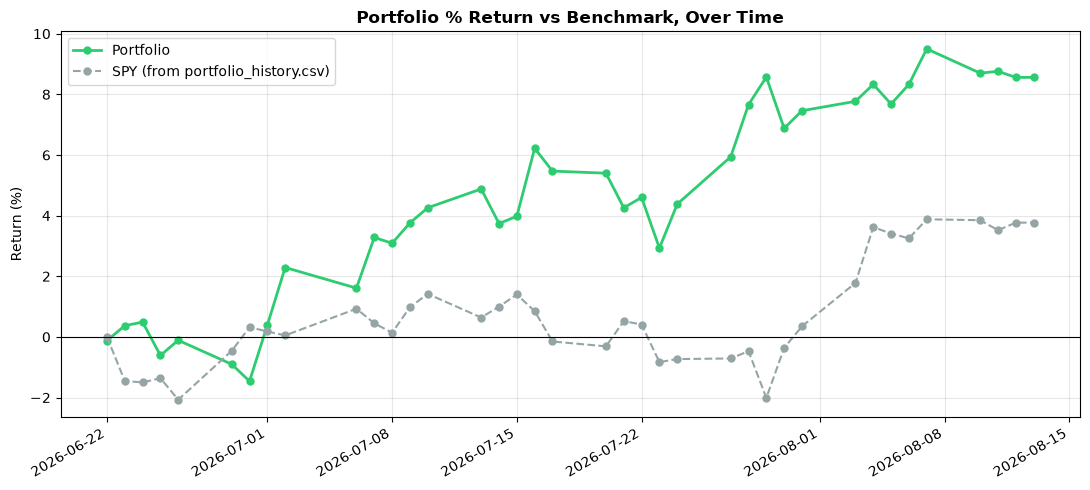

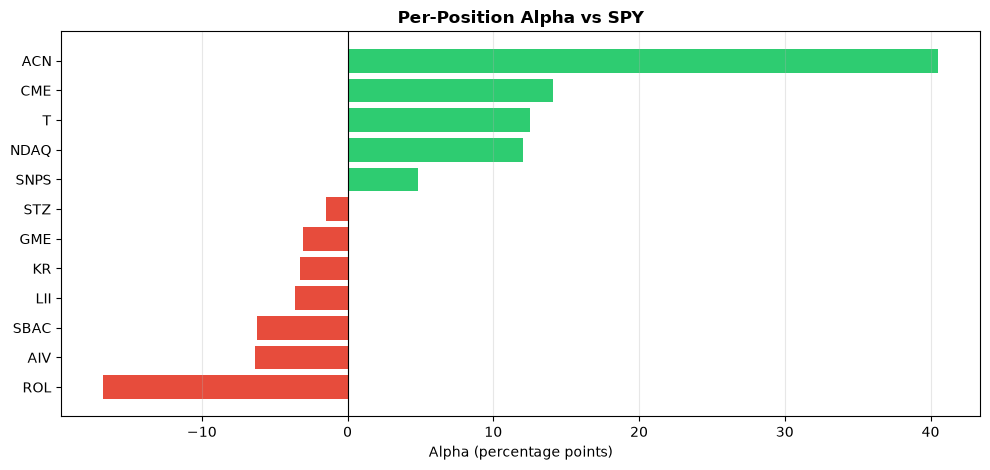

In [48]:
# Track Recorded Positions vs VOO
"""
Reads positions.csv (the same file record_position() writes to) and shows,
for each recorded position, its return since entry alongside what the same
holding period would have returned in VOO — the signal values captured at
entry time (composite_score, RSI, z_score, etc.) are shown alongside, as
your original reference point for that trade.

Also plots:
  1. Portfolio % change over time vs benchmark (from portfolio_history.csv,
     the daily automated tracker's output — that file tracks vs SPY, not
     VOO; labeled honestly as SPY below since that's what's actually
     computed there, distinct from the per-position VOO comparison here)
  2. Per-stock alpha bar chart (from the per-position comparison below,
     vs VOO)

This is a read-only view for ad-hoc inspection inside the notebook. The
demo-portfolio-tracker workflow is the authoritative, automated version of
the time-series tracking — this cell just lets you see the same picture
without leaving the notebook.
"""

import matplotlib.pyplot as plt
import yfinance as yf

BENCHMARK_TICKER = "SPY"
PORTFOLIO_HISTORY_PATH = "portfolio_history.csv"

RUN_TRACK_POSITIONS = True   # True/False: run the comparison below
PLOT_PORTFOLIO_VS_BENCHMARK = True   # True/False: time-series line chart
PLOT_PER_STOCK_ALPHA        = True   # True/False: per-position bar chart


def track_positions_vs_benchmark(positions_csv_path=POSITIONS_CSV_PATH, benchmark=BENCHMARK_TICKER):
    path = Path(positions_csv_path)
    if not path.exists():
        print(f"⚠️  {positions_csv_path} not found — no positions recorded yet.")
        return None

    positions = pd.read_csv(path, parse_dates=["entry_date", "exit_date"])
    if positions.empty:
        print("⚠️  positions.csv is empty.")
        return None

    rows = []
    for _, pos in positions.iterrows():
        ticker = pos["ticker"]
        entry_date = pos["entry_date"]
        entry_price = pos["entry_price"]

        if pos["status"] == "closed" and pd.notna(pos.get("exit_price")):
            end_date = pos["exit_date"]
            price_now = pos["exit_price"]
        else:
            end_date = pd.Timestamp.today()
            hist = yf.Ticker(ticker).history(period="5d")
            if hist.empty:
                continue
            price_now = float(hist["Close"].iloc[-1])

        position_return_pct = (price_now - entry_price) / entry_price * 100

        # Same holding period, but in the benchmark
        bench_hist = yf.Ticker(benchmark).history(
            start=entry_date.strftime("%Y-%m-%d"),
            end=(end_date + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        )
        if bench_hist.empty:
            continue
        bench_entry = float(bench_hist["Close"].iloc[0])
        bench_end   = float(bench_hist["Close"].iloc[-1])
        bench_return_pct = (bench_end - bench_entry) / bench_entry * 100

        alpha_pct = position_return_pct - bench_return_pct

        rows.append({
            "ticker":            ticker,
            "status":            pos["status"],
            "entry_date":        entry_date.date(),
            "entry_price":       round(entry_price, 2),
            "price_now":         round(price_now, 2),   # current price (open) or exit price (closed) — one consistent column
            "return_pct":        round(position_return_pct, 2),
            f"{benchmark}_return_pct": round(bench_return_pct, 2),
            "alpha_pct":         round(alpha_pct, 2),
            "composite_score":   pos.get("composite_score"),
            "rsi":               pos.get("rsi"),
            "z_score":           pos.get("z_score"),
            "pcr_volume":        pos.get("pcr_volume"),
            "sector":            pos.get("sector"),
        })

    result = pd.DataFrame(rows)
    return result


def plot_portfolio_vs_benchmark(history_path=PORTFOLIO_HISTORY_PATH):
    path = Path(history_path)
    if not path.exists():
        print(f"⚠️  {history_path} not found — the daily tracker hasn't run yet.")
        return

    hist = pd.read_csv(path, parse_dates=["date"]).sort_values("date")
    if hist.empty:
        print("⚠️  portfolio_history.csv is empty.")
        return

    if len(hist) == 1:
        print("ℹ️  Only 1 data point so far — the line will just show a single marker. "
              "Run the tracker a few more times (or wait for the daily cron once enabled) to see an actual trend.")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(hist["date"], hist["portfolio_return_pct"], label="Portfolio", color="#2ecc71", linewidth=2, marker="o", markersize=5)
    ax.plot(hist["date"], hist["spy_return_pct"], label="SPY (from portfolio_history.csv)", color="#95a5a6", linewidth=1.5, linestyle="--", marker="o", markersize=5)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Portfolio % Return vs Benchmark, Over Time", fontweight="bold")
    ax.set_ylabel("Return (%)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    if len(hist) > 1:
        fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


def plot_per_stock_alpha(comparison_df, benchmark=BENCHMARK_TICKER):
    if comparison_df is None or comparison_df.empty:
        print("⚠️  No comparison data to plot.")
        return

    df = comparison_df.sort_values("alpha_pct")
    colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in df["alpha_pct"]]

    fig, ax = plt.subplots(figsize=(10, max(3, len(df) * 0.4)))
    ax.barh(df["ticker"], df["alpha_pct"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Per-Position Alpha vs {benchmark}", fontweight="bold")
    ax.set_xlabel("Alpha (percentage points)")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


comparison_df = None
if RUN_TRACK_POSITIONS:
    comparison_df = track_positions_vs_benchmark()
    if comparison_df is not None:
        print(f"{len(comparison_df)} tracked positions vs {BENCHMARK_TICKER}:")
        display(comparison_df)

        avg_alpha = comparison_df["alpha_pct"].mean()
        win_rate = (comparison_df["alpha_pct"] > 0).mean() * 100
        print(f"\nAvg alpha vs {BENCHMARK_TICKER}: {avg_alpha:+.2f}pp  |  Beat benchmark: {win_rate:.0f}% of positions")

if PLOT_PORTFOLIO_VS_BENCHMARK:
    plot_portfolio_vs_benchmark()

if PLOT_PER_STOCK_ALPHA:
    plot_per_stock_alpha(comparison_df)
